# FHR-DQN vs baseline DQN — MountainCar comparison

One config (`config_fhrdqn.yaml`), one code path (`FHRDQNAgent`), one difference:
the **baseline arm** strips the FHR term (`fhr_weight: 0.0`, which reproduces plain
`QAgent` training exactly — verified bit-for-bit in `tests/test_fhrdqn.py`), the
**FHR arm** runs the config as-is. Both arms share the same seed (`load_config`
seeds torch/numpy/random on every call). Single seed for now.

MountainCar trains mid-episode (`use_episode_training: False`), so `train_diagnostics.csv`
holds one row per gradient step — the comparison plots aggregate per episode.
The baseline `exp1.ipynb` run showed the greedy-rollout Hankel of Q/V collapsing to
effective rank 1–2 from episode 50 onward (the constant `-1`/step reward makes the
Bellman recurrence roots {1, 1/gamma}), so the order-2 pure-AR penalty targets
structure that is genuinely present here.

Toggles to explore after this run (edit the config, rerun the FHR arm):
- `reward_lags: True` — ARX variant: learned reward-lag coefficients `d_k`, makes the exact Bellman recurrence representable at order 1.
- `analysis.hankel_sweep.enabled: true` / `autoregressive_value_probe.enabled: true` — Hankel-rank + held-out AR-fit diagnostics for the mechanism plots.

All artifacts land under `runs/<name>_<timestamp>/` and are browsable in the web app:
`python result_viewer_app/rank_viewer.py` → the *Training diagnostics* card shows the
TD loss, penalty and coefficient curves per run.


In [1]:
import copy, csv, sys, pathlib
import matplotlib.pyplot as plt
import numpy as np
import torch.nn as nn

SRC = pathlib.Path.cwd().parents[1] / "src"
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

from experiment import load_config, build_env, build_agent, train, make_run_logger
from agents.fhrdqn_agent import FHRDQNAgent

CONFIG = "config_fhrdqn.yaml"

In [2]:
class QNetwork(nn.Module):
    """Maps a state (obs_dim,) -> Q-values (n_actions,). Built by the agent via q_network(**nn_extra_kwargs)."""
    def __init__(self, in_dim, out_dim, hidden_sizes=(64, 64)):
        super().__init__()
        layers, last = [], in_dim
        for h in hidden_sizes:
            layers += [nn.Linear(last, h), nn.ReLU()]
            last = h
        layers.append(nn.Linear(last, out_dim))
        self.net = nn.Sequential(*layers)
    def forward(self, x):
        return self.net(x)

## Baseline arm — the regular config without the FHR term

`fhr_weight: 0.0` is the only override; everything else (buffer, sampling
distribution, TD computation, schedules) is identical to the FHR arm.

In [3]:
cfg_base = load_config(CONFIG)                    # seeds torch / numpy / random
cfg_base["experiment"]["name"] += "_baseline"
cfg_base["agent"]["fhr_weight"] = 0.0             # the single difference
env = build_env(cfg_base)
nn_extra_kwargs = {"in_dim": env.observation_space.shape[0],
                   "out_dim": env.action_space.n,
                   "hidden_sizes": cfg_base["network"]["hidden_sizes"]}
agent_base = build_agent(cfg_base, env, QNetwork, nn_extra_kwargs, agent_cls=FHRDQNAgent)
logger_base = make_run_logger(cfg_base, config_path=CONFIG)
rewards_base = train(cfg_base, agent_base, env, run_logger=logger_base)
run_dir_base = logger_base.dir
run_dir_base

  0%|          | 0/2000 [00:00<?, ?it/s]

  1%|          | 12/2000 [00:00<00:17, 111.40it/s]

  1%|          | 24/2000 [00:00<00:17, 116.12it/s]

episode 0 avg_rewarg: -200.0


  2%|▏         | 36/2000 [00:00<00:16, 117.68it/s]

...

100%|█████████▉| 1999/2000 [10:36<00:00,  3.12it/s]

100%|██████████| 2000/2000 [10:36<00:00,  2.94it/s]

100%|██████████| 2000/2000 [10:36<00:00,  3.14it/s]

run artifacts saved under /home/souparna/Low-Rank-RL-TL/experiments/dqn_mountaincar/runs/dqn_mountaincar_fhrdqn_baseline_20260811-161145


PosixPath('/home/souparna/Low-Rank-RL-TL/experiments/dqn_mountaincar/runs/dqn_mountaincar_fhrdqn_baseline_20260811-161145')

## FHR arm — config as-is

`load_config` is called again so this arm starts from the identical seed state.

In [4]:
cfg_fhr = load_config(CONFIG)                     # re-seeds: same seed as the baseline arm
env = build_env(cfg_fhr)
agent_fhr = build_agent(cfg_fhr, env, QNetwork, nn_extra_kwargs, agent_cls=FHRDQNAgent)
logger_fhr = make_run_logger(cfg_fhr, config_path=CONFIG)
rewards_fhr = train(cfg_fhr, agent_fhr, env, run_logger=logger_fhr)
run_dir_fhr = logger_fhr.dir
run_dir_fhr

  0%|          | 0/2000 [00:00<?, ?it/s]

  1%|          | 12/2000 [00:00<00:16, 117.62it/s]

episode 0 avg_rewarg: -200.0


  1%|          | 24/2000 [00:00<00:16, 118.46it/s]

  2%|▏         | 36/2000 [00:00<00:16, 118.76it/s]

...

 38%|███▊      | 760/2000 [07:09<08:31,  2.42it/s]

 38%|███▊      | 761/2000 [07:09<08:42,  2.37it/s]

 38%|███▊      | 761/2000 [07:10<11:40,  1.77it/s]

Average trajectory (episode total) reward for 50 episodes is -109.98
Triggering Early Stopping !!
run artifacts saved under /home/souparna/Low-Rank-RL-TL/experiments/dqn_mountaincar/runs/dqn_mountaincar_fhrdqn_20260811-162222


PosixPath('/home/souparna/Low-Rank-RL-TL/experiments/dqn_mountaincar/runs/dqn_mountaincar_fhrdqn_20260811-162222')

## Comparison figures

Each figure is shown inline and saved as `figures/comparison_<slug>.png` into **both**
run directories, so either run's page in the result viewer carries the full comparison.
Diagnostics are one row per gradient step here, so everything is aggregated to
per-episode means before plotting.

In [5]:
def read_diagnostics(run_dir):
    """train_diagnostics.csv -> {column: np.array}, aggregated to per-episode
    means (MountainCar logs one row per gradient step)."""
    path = pathlib.Path(run_dir) / "train_diagnostics.csv"
    with open(path) as f:
        rows = list(csv.DictReader(f))
    raw = {k: np.array([float(r[k]) for r in rows]) for k in rows[0]}
    episodes = np.unique(raw["episode"])
    agg = {"episode": episodes}
    for k, v in raw.items():
        if k == "episode":
            continue
        agg[k] = np.array([np.nanmean(v[raw["episode"] == e]) for e in episodes])
    return agg

diag_base = read_diagnostics(run_dir_base)
diag_fhr = read_diagnostics(run_dir_fhr)

def save_and_show(fig, slug):
    for d in (run_dir_base, run_dir_fhr):
        figdir = pathlib.Path(d) / "figures"
        figdir.mkdir(exist_ok=True)
        fig.savefig(figdir / f"comparison_{slug}.png", dpi=150, bbox_inches="tight")
    plt.show()

def rolling(x, w=50):
    x = np.asarray(x, dtype=float)
    if len(x) < w:
        return x
    return np.convolve(x, np.ones(w) / w, mode="valid")

/tmp/ipykernel_54346/1566069487.py:13: RuntimeWarning: Mean of empty slice
  agg[k] = np.array([np.nanmean(v[raw["episode"] == e]) for e in episodes])


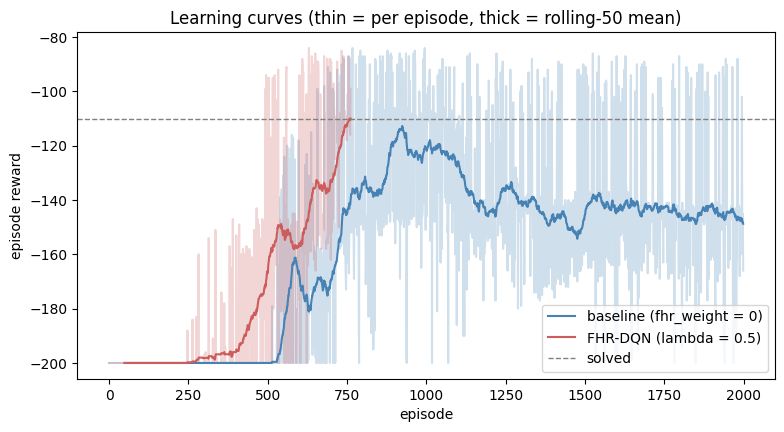

In [6]:
# -- learning curves ---------------------------------------------------------
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(rewards_base, alpha=0.25, color="steelblue")
ax.plot(rewards_fhr, alpha=0.25, color="indianred")
ax.plot(np.arange(len(rolling(rewards_base))) + 49, rolling(rewards_base),
        color="steelblue", label="baseline (fhr_weight = 0)")
ax.plot(np.arange(len(rolling(rewards_fhr))) + 49, rolling(rewards_fhr),
        color="indianred", label=f"FHR-DQN (lambda = {cfg_fhr['agent']['fhr_weight']})")
ax.axhline(cfg_fhr["training"]["solved_reward"], ls="--", c="gray", lw=1, label="solved")
ax.set_xlabel("episode"); ax.set_ylabel("episode reward")
ax.set_title("Learning curves (thin = per episode, thick = rolling-50 mean)")
ax.legend()
save_and_show(fig, "learning_curves")

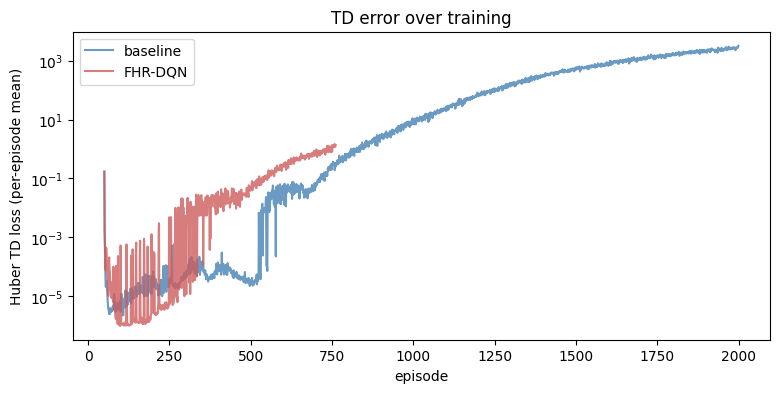

In [7]:
# -- TD error over training --------------------------------------------------
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(diag_base["episode"], diag_base["td_loss"], color="steelblue", alpha=0.8,
        label="baseline")
ax.plot(diag_fhr["episode"], diag_fhr["td_loss"], color="indianred", alpha=0.8,
        label="FHR-DQN")
ax.set_xlabel("episode"); ax.set_ylabel("Huber TD loss (per-episode mean)")
ax.set_yscale("log")
ax.set_title("TD error over training")
ax.legend()
save_and_show(fig, "td_error")

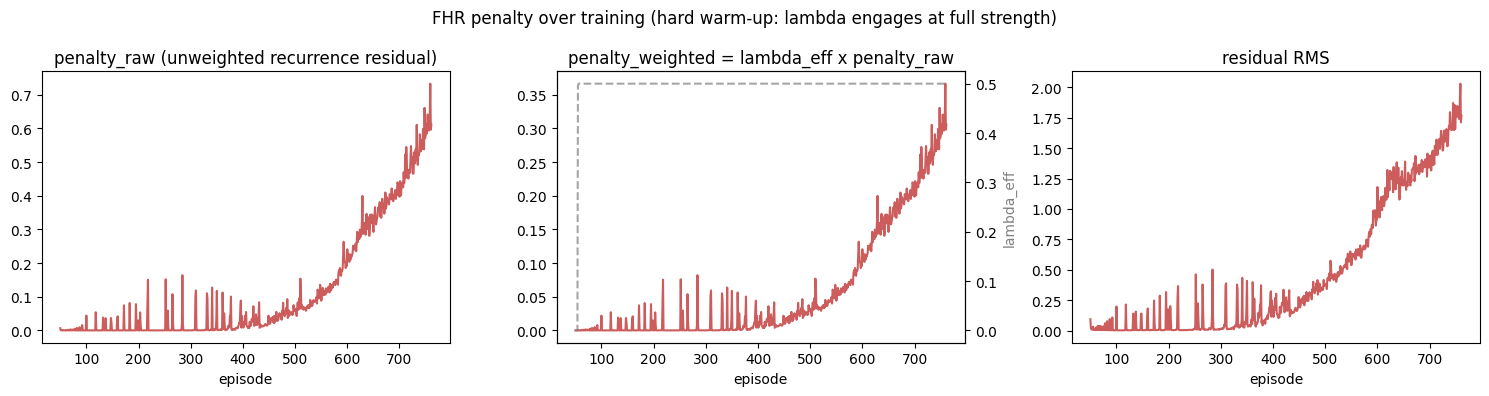

In [8]:
# -- regularisation penalty over training ------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].plot(diag_fhr["episode"], diag_fhr["penalty_raw"], color="indianred")
axes[0].set_title("penalty_raw (unweighted recurrence residual)")
axes[1].plot(diag_fhr["episode"], diag_fhr["penalty_weighted"], color="indianred")
axes[1].set_title("penalty_weighted = lambda_eff x penalty_raw")
ax2 = axes[1].twinx()
ax2.plot(diag_fhr["episode"], diag_fhr["lambda_eff"], color="gray", ls="--", alpha=0.7)
ax2.set_ylabel("lambda_eff", color="gray")
axes[2].plot(diag_fhr["episode"], diag_fhr["residual_rms"], color="indianred")
axes[2].set_title("residual RMS")
for ax in axes:
    ax.set_xlabel("episode")
fig.suptitle("FHR penalty over training (hard warm-up: lambda engages at full strength)")
fig.tight_layout()
save_and_show(fig, "penalty")

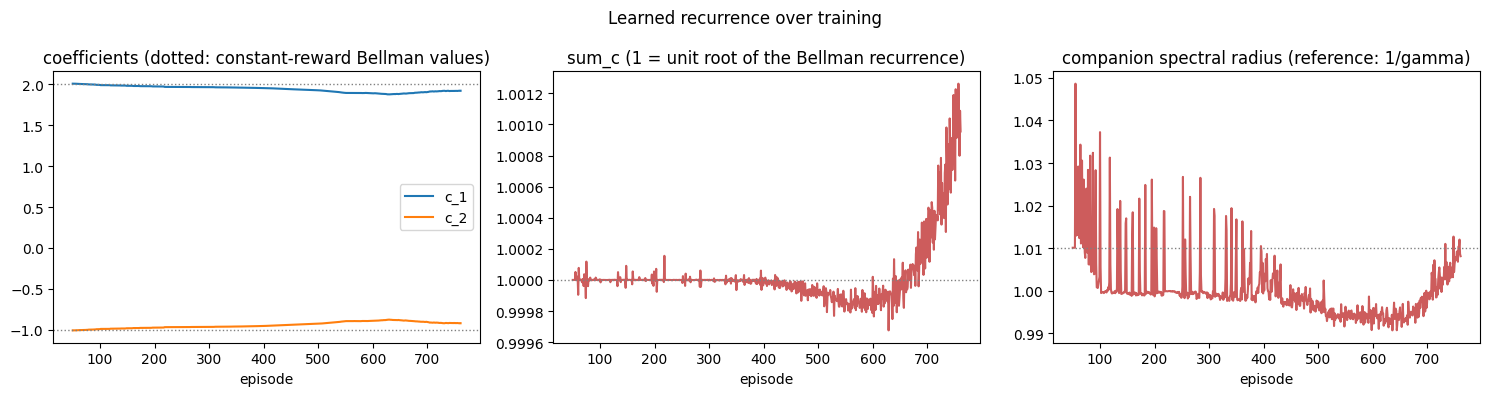

In [9]:
# -- learned recurrence coefficients ----------------------------------------
gamma = cfg_fhr["agent"]["discount_factor"]
r = cfg_fhr["agent"]["fhr_order"]
c_cols = [f"c_{j}" for j in range(1, r + 1) if f"c_{j}" in diag_fhr]
d_cols = [f"d_{j}" for j in range(1, r + 1) if f"d_{j}" in diag_fhr]
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for col in c_cols + d_cols:
    axes[0].plot(diag_fhr["episode"], diag_fhr[col], label=col)
axes[0].axhline(1 + 1 / gamma, ls=":", c="gray", lw=1)
axes[0].axhline(-1 / gamma, ls=":", c="gray", lw=1)
axes[0].set_title("coefficients (dotted: constant-reward Bellman values)")
axes[0].legend()
axes[1].plot(diag_fhr["episode"], diag_fhr["sum_c"], color="indianred")
axes[1].axhline(1.0, ls=":", c="gray", lw=1)
axes[1].set_title("sum_c (1 = unit root of the Bellman recurrence)")
axes[2].plot(diag_fhr["episode"], diag_fhr["companion_radius"], color="indianred")
axes[2].axhline(1 / gamma, ls=":", c="gray", lw=1)
axes[2].set_title("companion spectral radius (reference: 1/gamma)")
for ax in axes:
    ax.set_xlabel("episode")
fig.suptitle("Learned recurrence over training")
fig.tight_layout()
save_and_show(fig, "coefficients")

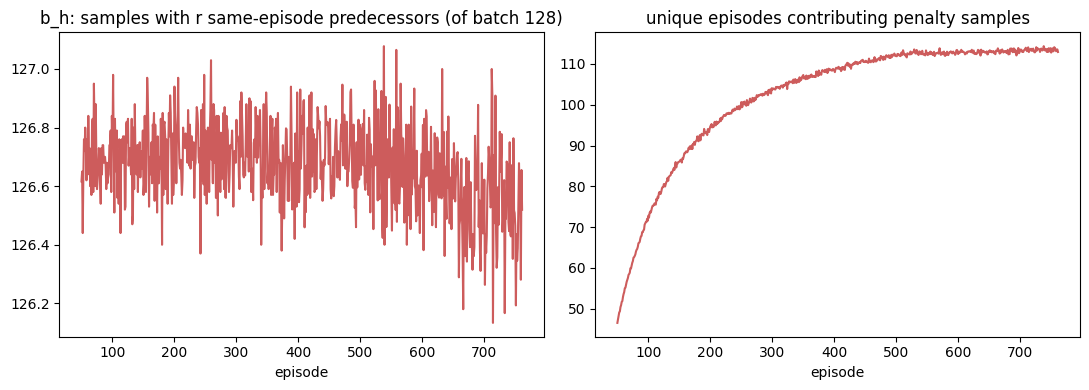

In [10]:
# -- penalty batch composition ----------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(diag_fhr["episode"], diag_fhr["b_h"], color="indianred")
axes[0].set_title("b_h: samples with r same-episode predecessors (of batch %d)"
                  % cfg_fhr["agent"]["batch_size"])
axes[1].plot(diag_fhr["episode"], diag_fhr["unique_eps"], color="indianred")
axes[1].set_title("unique episodes contributing penalty samples")
for ax in axes:
    ax.set_xlabel("episode")
fig.tight_layout()
save_and_show(fig, "penalty_batch")

In [11]:
# -- summary -----------------------------------------------------------------
def solve_episode(rewards, solved, patience=50):
    roll = rolling(rewards, patience)
    idx = np.argmax(roll > solved)
    return int(idx + patience) if roll.max() > solved else None

solved = cfg_fhr["training"]["solved_reward"]
print(f"baseline: {len(rewards_base)} episodes, best rolling-50 {rolling(rewards_base).max():.1f}, "
      f"solved at episode {solve_episode(rewards_base, solved)}")
print(f"FHR-DQN : {len(rewards_fhr)} episodes, best rolling-50 {rolling(rewards_fhr).max():.1f}, "
      f"solved at episode {solve_episode(rewards_fhr, solved)}")
print(f"final coefficients: " + ", ".join(
    f"{c}={diag_fhr[c][-1]:.4f}" for c in c_cols + d_cols)
    + f" | sum_c={diag_fhr['sum_c'][-1]:.4f}"
    + f" | companion radius={diag_fhr['companion_radius'][-1]:.4f} (1/gamma={1/gamma:.4f})")
print(f"nan_skips: baseline {diag_base['nan_skips'][-1]:.0f}, FHR {diag_fhr['nan_skips'][-1]:.0f}")

baseline: 2000 episodes, best rolling-50 -112.7, solved at episode None
FHR-DQN : 762 episodes, best rolling-50 -110.0, solved at episode 762
final coefficients: c_1=1.9232, c_2=-0.9223 | sum_c=1.0010 | companion radius=1.0081 (1/gamma=1.0101)
nan_skips: baseline 0, FHR 0
